# PCA

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [Data Exploration](#de)
3. [Standarization](#STAND)
4. [Covariance Matrix](#CM)
5. [Interpretation Principal Compoments](#IPC)
6. [Dimensionality Reduction](#DR)
7. [Exercise](#exercise)

<div class="alert alert-warning">
    <b> I. <i>Introduction </i></b>
    <a id="introduction"></a></div>

In this notebook, we will introduce Principal Component Analysis (PCA), a powerful technique used in machine learning and statistics for dimensionality reduction.

Datasets often contain many features that may be correlated or redundant. Working with high-dimensional data can make models more complex, slower, and harder to interpret. PCA helps address this problem by transforming the original features into a new set of variables called principal components. They are linear combinations of the original features and are uncorrelated to each other.  

By selecting only the top few principal components, we can reduce the number of dimensions and retain most of the important information. 

Let's import the necessary libraries:

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

<div class="alert alert-warning">
    <b> II. <i>Data Exploration </i></b>
    <a id="de"></a></div>

In this step, we load and inspect the dataset to understand its structure and contents before applying any transformations. We are using the Wine dataset, which contains chemical properties of different wine samples along with their class labels.

In [194]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("First 5 rows:")
print(df.head())

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target

Before applying PCA or any machine learning method, it’s important to understand the number of features and samples and check how data is structured.

<div class="alert alert-warning">
    <b> III. <i>Standarization</i></b>
    <a id="STAND"></a></div>

Before applying PCA, we standardize the data so that each feature contributes fairly to the analysis.

In [195]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<div class="alert alert-warning">
    <b> IV. <i>Covariance Matrix</i></b>
    <a id="CM"></a></div>

After standardizing the data, the next step is to compute the covariance matrix, which helps us understand how features vary together. We want to measure the relationship between two variables. The positive covariance means both variables increase together, negative covariance indicates that one increases while the other decreases. If we have a near zero value indicates that there is little or no linear relationship.

In [196]:
cov_matrix = np.cov(X_scaled.T) # X_scales has shape (samples, features), 
                                # np.cov() expects variables as rows, we transpose and get (features, samples)
cov_df = pd.DataFrame(cov_matrix, 
                      columns=feature_names, 
                      index=feature_names)

Let's visualize the covariance matrix:

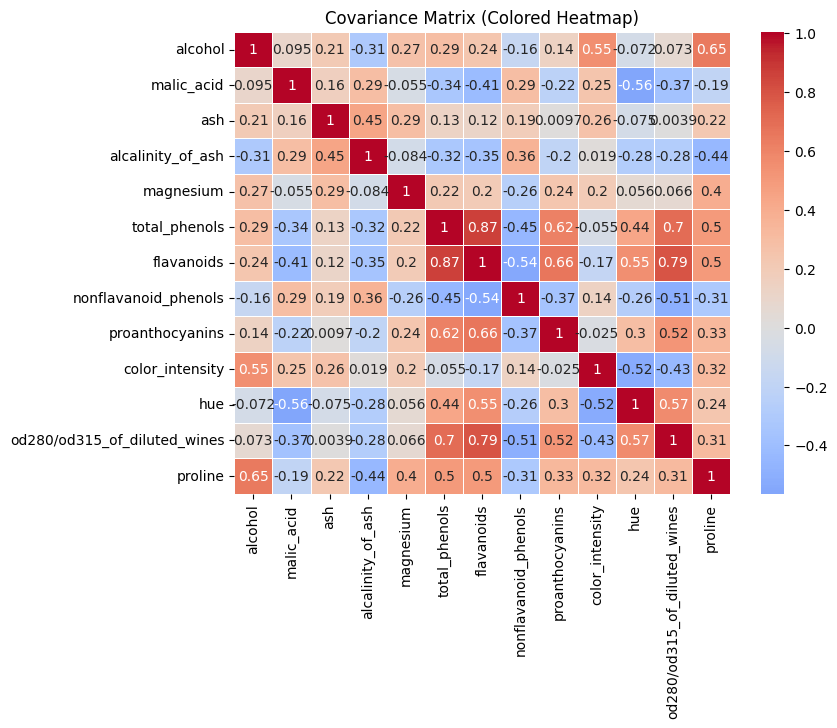

In [197]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cov_df,
    annot=True,        # show numbers
    cmap="coolwarm",   # color scheme 
    center=0,          # zero = neutral color
    linewidths=0.5
)

plt.title("Covariance Matrix (Colored Heatmap)")
plt.show()

We can see some strong positive relationships: 
- ``flavanoids`` ↔ ``total_phenols`` (~0.87)
- ``flavanoids`` ↔ ``od280/od315_of_diluted_wines`` (~0.79)
- ``total_phenols`` ↔``od280/od315_of_diluted_wines``(~0.70)
These features carry similar information and are redundant. 

We also can see strong negative relationships: 
- ``flavanoids`` ↔ ``nonflavanoid_phenols`` (~-0.54)
- ``color_intensity`` ↔ ``hue`` (~-0.52)
These features move in opposite directions.

We can also see many near zero values. 

__What will do PCA?__

PCA will take strong correlations and compress them into fewer components and removing redundant variables. It will also build components that capture opposing relationships. 

<div class="alert alert-warning">
    <b> V. <i>Interpretation Principal Components</i></b>
    <a id="IPC"></a></div>

Let's compute PCA.

In [198]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

After computing it, we will not use the original features like alcohol, flavanoids, etc; we will use the new created features like PC1 and PC2. 

With parameter ``n_components``, we indicate the number of new features. In this case, I reduce the 13 features of the original dataset into 3 new features. Thes features are ``Principal Component 1 (PC1)``, ``Principal Component 2 (PC2)`` and ``Principal Component 3 (PC3)``.

Principal components are new features created by mixing the original features together in specific proportions.

The first new feature (PC1) is constructed to capture as much variation in the data as possible. The second one (PC2) captures the next largest amount of variation, but in a way that is independent (uncorrelated) with PC1. This process continues for all remaining components. However, these components are harder to interpret because they do not represent real-world variables. Instead, they are mathematical combinations (linear combinations) of the original features.

We can visualize PCA using a cloud of points in space, where each axis represents a feature such as alcohol or flavanoids. PCA tries to find a line that goes through the center of this cloud and in the direction where the points are most spread out when projected onto it. This direction becomes PC1.

After finding PC1, PCA then looks for another line that is perpendicular (uncorrelated) to PC1 and captures the next highest amount of variation in the data. This becomes PC2. The process continues in the same way for the remaining components until all are constructed. 


![PCA animation](https://builtin.com/sites/www.builtin.com/files/inline-images/national/Principal%2520Component%2520Analysis%2520second%2520principal.gif)



In [199]:
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by PC1 + PC2 + PC3:")
print(sum(pca.explained_variance_ratio_))


Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631]

Total variance explained by PC1 + PC2 + PC3:
0.6652996889318524


We can see how many variance each PC keeps from the original dataset. PC1 explains 36.2% of the total variance, PC2 19.2% and PC3 11.1%. The 3 principal components together capture about 66.5% of all the information in the original dataset.

More information about PCA: [LINK](https://builtin.com/data-science/step-step-explanation-principal-component-analysis)

<div class="alert alert-warning">
    <b> VI. <i>Dimensionality Reduction</i></b>
    <a id="DR"></a></div>

Let's visualize the data. First, we create a table of the data and each PC:

In [200]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2','PC3'])
pca_df['target'] = y

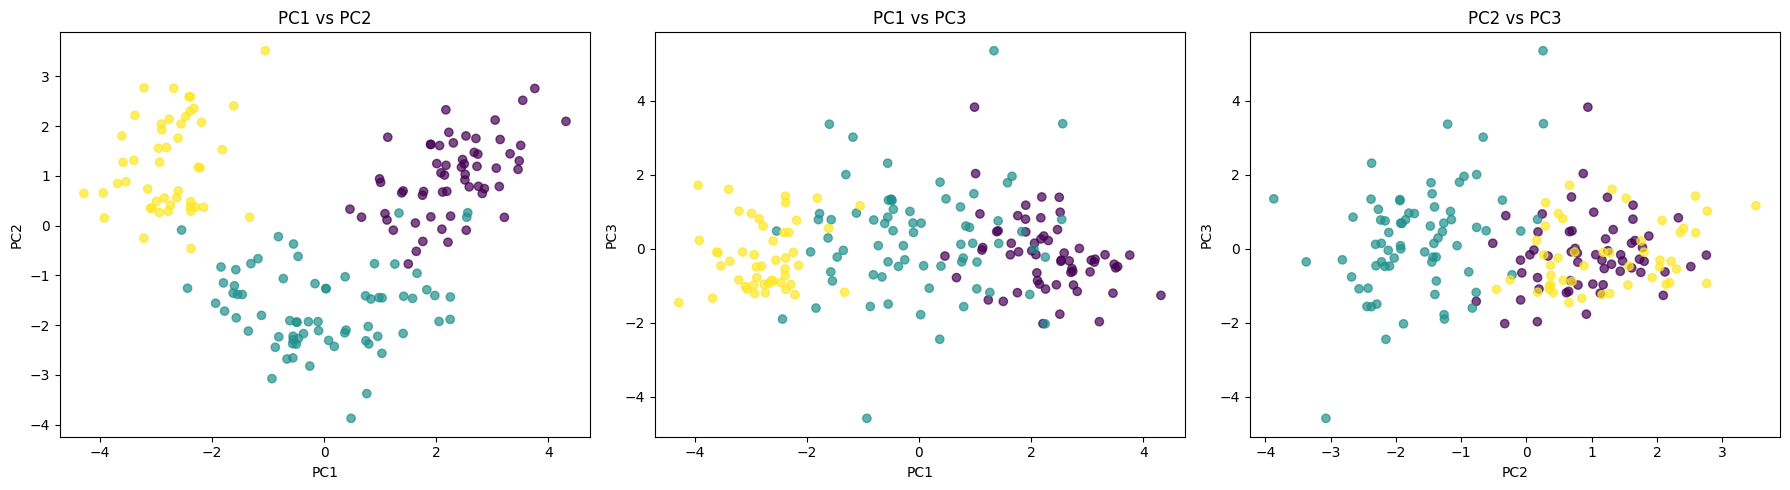

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2
axes[0].scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['target'], alpha=0.7)
axes[0].set_title("PC1 vs PC2")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# PC1 vs PC3
axes[1].scatter(pca_df['PC1'], pca_df['PC3'], c=pca_df['target'], alpha=0.7)
axes[1].set_title("PC1 vs PC3")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")

# PC2 vs PC3
axes[2].scatter(pca_df['PC2'], pca_df['PC3'], c=pca_df['target'], alpha=0.7)
axes[2].set_title("PC2 vs PC3")
axes[2].set_xlabel("PC2")
axes[2].set_ylabel("PC3")

plt.tight_layout()
plt.show()

Each scatter plot shows a different view of the data. PC1 vs PC2 plot shows a clear clustering structure and the groups are clearly separated, which means that PC1 and PC2 capture the most meaningful variation in our data. 
The middle plot PC1 VS PC3 shows a more weak separation and points overlap between classes meaning that PC3 contributes less to the discrimination between classes. 
The last plot between PC2 vs PC3 shows the classes clearly overlap. We can see that PC1 carries the strongest signal to separate groups. 

In [202]:
print("\nPCA Components (how original features contribute):")
components = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2', 'PC3']
)
print(components)


PCA Components (how original features contribute):
      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1  0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2  0.483652    0.224931  0.316069          -0.010591   0.299634   
PC3 -0.207383    0.089013  0.626224           0.612080   0.130757   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
PC1       0.394661    0.422934             -0.298533         0.313429   
PC2       0.065040   -0.003360              0.028779         0.039302   
PC3       0.146179    0.150682              0.170368         0.149454   

     color_intensity       hue  od280/od315_of_diluted_wines   proline  
PC1        -0.088617  0.296715                      0.376167  0.286752  
PC2         0.529996 -0.279235                     -0.164496  0.364903  
PC3        -0.137306  0.085222                      0.166005 -0.126746  


These values show how each original feature contributes to the principal components. We compute PCA to reduce the dimensionality of the dataset while preserving as much variance (information) as possible. Each principal component is a weighted combination of the original features, and the weights indicate their importance.
This helps simplify the data, remove redundancy, and make patterns easier to visualize and model.

For example, in PC1, flavanoids (0.42) and total_phenols (0.39) contribute strongly, so PC1 is largely driven by wine chemical quality traits.
In PC2, color_intensity (0.53) and alcohol (0.48) dominate, meaning this component captures variation in wine strength and appearance.

<div class="alert alert-warning">
    <b> VII. <i>Exercise</i></b>
    <a id="exercise"></a></div>

<div class="alert alert-info">

__Run PCA with different number of components__

__See how much variance each component has__

__Visualize the feature contribution to each PC__

In [ ]:
pca = ...
X_pca = ...

In [211]:
print("\nExplained Variance Ratio:")


print("\nTotal variance explained by PC1 + PC2")



Explained Variance Ratio:

Total variance explained by PC1 + PC2


In [210]:
print("\nPCA Components (how original features contribute):")



PCA Components (how original features contribute):


<div class="alert alert-info">

__Train a Decision Tree with PCA and compare the results without PCA__


In [206]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

Without PCA: 

With PCA:

In [ ]:
pca =...
X_pca =...